In [1]:
#### conda env Weather_Prediction

import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import pearsonr

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error


import shap
import os
import geopandas as gpd
pd.set_option('display.precision', 15)
pd.set_option('display.max_columns', None)

In [2]:
df1=pd.read_pickle('final_dataset_103_features_90th_percentile.pkl')
full_df = df1.drop(['fips', 'year'], axis=1)
full_df


,MeanLifeExpectency,2m dew point temperature,2m temperature,Black carbon AOD at 550 nm,Dust AOD at 550 nm,Land-sea mask,Mean sea level pressure,Organic matter AOD at 550 nm,PM$_1$,PM$_{2.5}$,PM$_{10}$,Sea salt AOD at 550 nm,Sulphate AOD at 550 nm,Surface geopotential,Surface pressure,Total AOD at 469 nm,Total AOD at 550 nm,Total AOD at 670 nm,Total AOD at 865 nm,Total AOD at 1240 nm,Total column carbon monoxide,Total column ethane,Total column formaldehyde,Total column hydrogen peroxide,Total column hydroxyl radical,Total column isoprene,Total column methane,Total column nitric acid,Total column nitrogen dioxide,Total column nitrogen monoxide,Total column ozone,Total column peroxyacetyl nitrate,Total column propane,Total column sulphur dioxide,Total column water vapour,Carbon monoxide,Dust aerosol (0.03-0.55 µm) mixing ratio,Dust aerosol (0.55-0.9 µm) mixing ratio,Dust aerosol (0.9-20 µm) mixing ratio,Ethane,Formaldehyde,Hydrogen peroxide,Hydrophilic black carbon aerosol mixing ratio,Hydrophilic organic matter aerosol mixing ratio,Hydrophobic black carbon aerosol mixing ratio,Hydrophobic organic matter aerosol mixing ratio,Hydroxyl radical,Isoprene,Nitric acid,Nitrogen dioxide,Nitrogen monoxide,Ozone,Peroxyacetyl nitrate,Propane,Sea salt aerosol (0.03-0.5 µm) mixing ratio,Sea salt aerosol (0.5-5 µm) mixing ratio,Sea salt aerosol (5-20 µm) mixing ratio,Specific humidity,Sulphate aerosol mixing ratio,Sulphur dioxide,Temperature,"Leaf area index, high vegetation","Leaf area index, low vegetation",Snow albedo,Snow depth,Total column water,Vertically integrated mass of dust aerosol (0.03-0.55 µm),Vertically integrated mass of dust aerosol (0.55-9 µm),Vertically integrated mass of dust aerosol (9-20 µm),Vertically integrated mass of hydrophilic black carbon aerosol,Vertically integrated mass of hydrophilic organic matter aerosol,Vertically integrated mass of hydrophobic black carbon aerosol,Vertically integrated mass of hydrophobic organic matter aerosol,Vertically integrated mass of sea salt aerosol (0.03-0.5 µm),Vertically integrated mass of sea salt aerosol (0.5-5 µm),Vertically integrated mass of sea salt aerosol (5-20 µm),Vertically integrated mass of sulphate aerosol,Vertically integrated mass of sulphur dioxide,Relative humidity,10m wind speed,Wet bulb temperature,FoT Carbonmonoxide above 90ᵗʰ percentile,FoT Ethane above 90ᵗʰ percentile,FoT Formaldehyde above 90ᵗʰ percentile,FoT Hydroxyl radical above 90ᵗʰ percentile,FoT Isoprene above 90ᵗʰ percentile,FoT Peroxyacetyl Nitrate above 90ᵗʰ percentile,FoT Nitric acid above 90ᵗʰ percentile,FoT Nitrogen dioxide above 90ᵗʰ percentile,FoT Nitrogen monoxide above 90ᵗʰ percentile,FoT Ozone above 90ᵗʰ percentile,FoT Hydrogen peroxide above 90ᵗʰ percentile,FoT PM$_{10}$ above 90ᵗʰ percentile,FoT PM$_{1}$ above 90ᵗʰ percentile,FoT PM$_{2.5}$ above 90ᵗʰ percentile,FoT Propane above 90ᵗʰ percentile,FoT Sulphur dioxide above 90ᵗʰ percentile,FoT Temperature above 90ᵗʰ percentile,FoT Temperature below 10ᵗʰ percentile,FoT PM$_{10}$ above EPA threshold,FoT Temperature above 90 $\mathrm{^o F}$,FoT Temperature below 0 $\mathrm{^o C}$,FoT PM$_{2.5}$ above EPA threshold
0,74.628765329999993,285.629269414872169,290.863352214209158,0.00757124815486,0.010371692890225,0.986464531564209,101746.46078524258337,0.097522246908886,0.000000015615338,0.000000019601377,0.000000027192044,0.00860619294015,0.112170314070482,1368.670051439976305,100086.817007783130975,0.288798537560071,0.236241944078782,0.180380990078313,0.123618863685572,0.069164993038643,0.000984550381998,0.000003862356441,0.000003599970514,0.000008836077454,0.000000004853489,0.000001984446001,0.009753834615672,0.000007246513254,0.000004130302193,0.000000542480041,0.006426156201957,0.000008713431766,0.00000074020297,0.000004737026637,25.902900677695214,0.000000230284119,0.000000000654884,0.000000001134462,0.000000000403961,0.000000000705993,0.000000003513651,0.000000000741261,0.00000000022451,0.000000010096395,0.000000000254529,0.000000005847693,0

## Using 15 features

In [3]:
fifteen_features= ['MeanLifeExpectency','Specific humidity','Leaf area index, low vegetation','Surface pressure',
                  'Leaf area index, high vegetation','Sulphate aerosol mixing ratio', 'Wet bulb temperature',
                  'Formaldehyde','Propane',
                 'FoT Carbonmonoxide above 90ᵗʰ percentile',
                  'Dust aerosol (0.03-0.55 µm) mixing ratio','Isoprene',
                  'Nitrogen dioxide', 'Hydrogen peroxide',
                  'Peroxyacetyl nitrate','Sulphur dioxide','10m wind speed']

In [4]:
full_df_fifteen = full_df.loc[:, fifteen_features]
full_df_fifteen

,MeanLifeExpectency,Specific humidity,"Leaf area index, low vegetation",Surface pressure,"Leaf area index, high vegetation",Sulphate aerosol mixing ratio,Wet bulb temperature,Formaldehyde,Propane,FoT Carbonmonoxide above 90ᵗʰ percentile,Dust aerosol (0.03-0.55 µm) mixing ratio,Isoprene,Nitrogen dioxide,Hydrogen peroxide,Peroxyacetyl nitrate,Sulphur dioxide,10m wind speed
0,74.628765329999993,0.010010040534155,2.618741604547198,100086.817007783130975,3.904460199286052,0.00000000404404,14.185547266162992,0.000000003513651,0.000000000328437,19.623287671232877,0.000000000654884,0.000000014604292,0.000000010235872,0.000000000741261,0.000000003056157,0.000000009229008,0.209342152896552
1,76.661419230000007,0.012053964031284,1.556460793604144,101507.029992429539561,2.493748263318578,0.000000003376943,16.735605496466448,0.000000001813065,0.000000000255961,6.061643835616438,0.000000000693319,0.000000003807398,0.000000006039749,0.000000000839633,0.000000001913777,0.000000004951391,0.42506917399947
2,74.047810630000001,0.010116411670589,2.367511530630567,100218.776953070439049,4.174570187840095,0.000000003173645,14.652120108679608,0.000000003130391,0.000000000302966,17.910958904109588,0.000000000696949,0.000000013132761,0.00000000807493,0.000000000760942,0.000000002668089,0.000000003391913,0.169872508900564
3,73.057987400000002,0.009712725129444,2.754823872966046,99965.021140069555258,3.638957935933739,0.000000004729935,13.829282111100266,0.000000003373964,0.000000000358899,21.301369863013701,0.0000000006092,0.000000013479486,0.000000013131751,0.000000000699918,0.000000003056251,0.000000013603814,0.247677504482458
4,75.053119350000003,0.009374448422807,2.78269651469914,99291.479349611210637,3.286418753252266,0.000000004897891,13.082501247882803,0.000000002956875,0.000000000399657,23.767123287671232,0.000000000565979,0.000000010923979,0.000000014273459,0.000000000648027,0.000000002906905,0.000000013819481,0.313663384140064
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52315,78.018891969999999,0.003747796333939,0.536378170765603,78504.848716287262505,3.538422076256631,0.000000001132903,0.571281695046519,0.000000000717546,0.000000000111938,17.294520547945204,0.000000000301368,0.000000001232036,0.00000000827787,0.000000000341813,0.000000001051317,0.000000004655746,1.605265246419298
52316,85.638149490000004,0.003688190466983,1.785488597639217,75982.937825419445289,2.670711888609032,0.000000000875683,-1.859769761436167,0.000000000717248,0.000000000117618,4.178082191780822,0.000000000144742,0.000000001264543,0.000000002819322,0.000000000321785,0.000000001017388,0.000000000165686,1.238102709958286
52317,77.521690719999995,0.004073729822701,0.674010337938586,77908.41730284303776,4.031189331292228,0.000000001089012,0.482583691619953,0.000000000815465,0.000000000158386,16.952054794520549,0.000000000192437,0.000000002141827,0.00000000751576,0.000000000338547,0.000000001095202,0.000000002105004,1.208359564739262
52318,78.137158389999996,0.004194294518206,0.526594406537813,81987.763448374767904,4.581955061795957,0.000000000867287,0.807879855752541,0.000000000684047,0.000000000108903,17.739726027397261,0.000000000231663,0.00000000077482,0.000000005035151,0.000000000291158,0.000000000972974,0.000000000795473,0.673376207603366


In [5]:
## Lets create a Train-Test set

features=full_df_fifteen.drop('MeanLifeExpectency',axis=1)
target=full_df_fifteen['MeanLifeExpectency'].copy()

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.20) 

In [6]:
## initial results

forest_reg=RandomForestRegressor(n_jobs=-1)
forest_reg.fit(X_train, y_train)

train_prediction=forest_reg.predict(X_train)

mse_train=mean_squared_error(y_train, train_prediction)
rmse_train=np.sqrt(mse_train)
rmse_train=int(rmse_train*100)/100 ## display only two digits without rounding

print('The train RMSE :::', '%.2f' % rmse_train)

The train RMSE ::: 0.44


In [7]:
## lets do a cross-validation to identify overfitting and test if there is variation in the output result,
## based on variability of the input data

scores=cross_val_score(forest_reg, X_train, y_train,
                        scoring='neg_mean_squared_error', cv=4, n_jobs=6) ## can select other scoring as well
                                                                          ## n_jobs uses the number of cores
rmse_scores=np.sqrt(-scores)
sd_rmse=rmse_scores.std()
avg_score=rmse_scores.mean()

In [8]:
print(f'RMSE scores for each fold: {rmse_scores}')
print(f'Mean RMSE score: {avg_score}')
print(f'Standard deviation of RMSE scores: {sd_rmse}')

RMSE scores for each fold: [1.26903849 1.27136456 1.23675036 1.23058219]
Mean RMSE score: 1.2519339005678174
Standard deviation of RMSE scores: 0.018415707450089823


In [9]:
%%time
## lets optimize the hyperparameters
forest_reg=RandomForestRegressor(n_jobs=-1, oob_score=True) ## also include oob score. this can be removed if not necessary

hyper_parameters=[{'n_estimators':[200, 300],'max_features': [10, 20], 'max_depth':[100, 150],
                                                              'min_samples_split':[ 10, 20]}]
grid_search=GridSearchCV(forest_reg,hyper_parameters,cv=4,scoring="neg_mean_squared_error",return_train_score=True, verbose=1)
grid_search.fit(X_train,y_train)

Fitting 4 folds for each of 16 candidates, totalling 64 fits
CPU times: total: 5h 1min 46s
Wall time: 20min 48s


,estimator,RandomForestR...ob_score=True)
,param_grid,"[{'max_depth': [100, 150], 'max_features': [10, 20], 'min_samples_split': [10, 20], 'n_estimators': [200, 300]}]"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,4
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,300


In [10]:
grid_search.best_estimator_

,n_estimators,300
,criterion,'squared_error'
,max_depth,100
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,20
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [11]:
## lets now select the model. This will be used later
final_model=grid_search.best_estimator_

In [12]:
## fit the model and find the error in the traning set

final_model.fit(X_train,y_train)

train_prediction=final_model.predict(X_train)

mse_train=mean_squared_error(y_train, train_prediction)
rmse_train=np.sqrt(mse_train)
rmse_train=int(rmse_train*100)/100 ## display only two digits without rounding

print('The train RMSE :::', '%.2f' % rmse_train)

The train RMSE ::: 0.62


In [13]:
## The test prediction

test_prediction=final_model.predict(X_test)

mse_test=mean_squared_error(y_test,test_prediction)
rmse_test=np.sqrt(mse_test)
rmse_test=int(rmse_test*100)/100 

print('The test RMSE :::', '%.2f' % rmse_test)

The test RMSE ::: 1.22


In [14]:
## the train r square

train_r_sq=(pearsonr(y_train,train_prediction)[0])**2
corr_train=int(train_r_sq*100)/100 ## display only two digits without rounding

print('The train r_sq :::', '%.2f' % corr_train)

The train r_sq ::: 0.94


In [15]:
## The test r square

test_r_sq=(pearsonr(y_test,test_prediction)[0])**2
corr_test=int(test_r_sq*100)/100 ## display only two digits without rounding

print('The test r_sq :::', '%.2f' % corr_test)

The test r_sq ::: 0.75


In [16]:
## calculate the adjusted r square

## in training set

n_train=X_train.shape[0] ## number of samples in training set
n_test=X_test.shape[0]  ## number of samples in test set
p=X_train.shape[1] ## number of features, which is the same in train and test set

train_adjusted_r2=1-(1-corr_train)*((n_train-1)/(n_train-p-1))
train_adjusted_r2=int(train_adjusted_r2*100)/100 ## display only two digits without rounding

test_adjusted_r2=1-(1-corr_test)*((n_test-1)/(n_test-p-1))
test_adjusted_r2=int(test_adjusted_r2*100)/100 ## display only two digits without rounding

print('The adjusted train r_sq :::', '%.2f' % train_adjusted_r2)
print('The adjusted test r_sq :::', '%.2f' % test_adjusted_r2)

The adjusted train r_sq ::: 0.93
The adjusted test r_sq ::: 0.74


In [17]:
## steps to convert train and test to pandas dataframe. This step is necessary to plot in seaborn

y_train_np=y_train.to_numpy() ## convert dtype to numpy to plot from seaborn
y_test_np=y_test.to_numpy() 

df1=pd.DataFrame(y_train_np, columns=['Actual'])
df2=pd.DataFrame(train_prediction, columns=['Estimated'])
df3=pd.concat([df1, df2],axis=1)  ## concatenate the columns
df3['Label']='Train'

df4=pd.DataFrame(y_test_np, columns=['Actual'])
df5=pd.DataFrame(test_prediction, columns=['Estimated'])
df6=pd.concat([df4, df5],axis=1)
df6['Label']='Test'

sns_df=pd.concat([df3,df6])

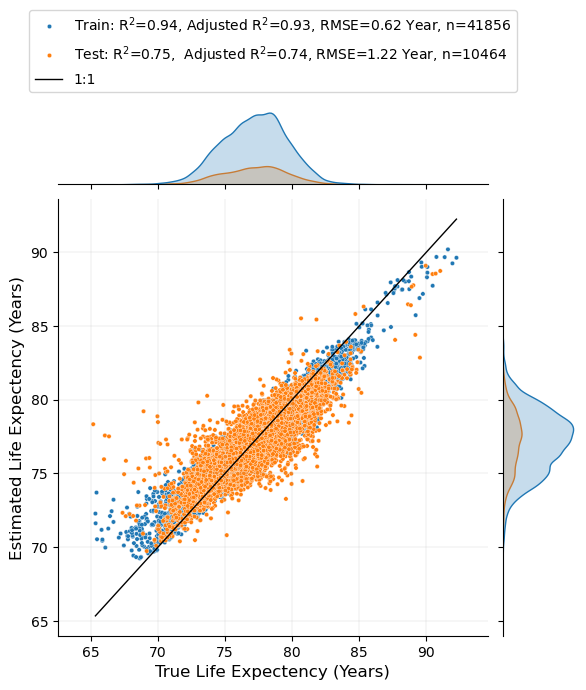

In [18]:
## scatter plot in seaborn

g=sns.jointplot(data=sns_df, x='Actual', y='Estimated', kind="scatter", hue='Label',s=10)
plt.grid(axis='both',linewidth=0.15)

p1 = max(max(train_prediction), max(y_train))
p2 = min(min(train_prediction), min(y_train))

g.ax_joint.plot([p1, p2], [p1, p2], color='k',linewidth=1, label='1:1')

# Customize the legend
handles, labels = g.ax_joint.get_legend_handles_labels()  



g.ax_joint.legend(handles=handles,  
    labels=[ f'Train: R$^2$={corr_train}, Adjusted R$^2$={train_adjusted_r2}, RMSE={rmse_train} Year, n={len(X_train)}', 
        f'Test: R$^2$={corr_test},  Adjusted R$^2$={test_adjusted_r2}, RMSE={rmse_test} Year, n={len(X_test)}','1:1'],
                        title=None)

sns.move_legend(g.ax_joint, "upper center", bbox_to_anchor=(0.5, 1.45))

g.set_axis_labels(r'True Life Expectency (Years)', r'Estimated Life Expectency (Years)',fontsize=12)

plt.show()

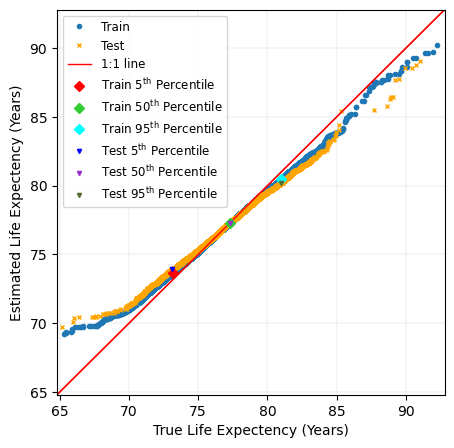

In [19]:
## Lets plot the quantile-quantile plot

fig, ax = plt.subplots(figsize=(5,5))

pp_x = sm.ProbPlot(y_train, fit=False)
pp_y = sm.ProbPlot(train_prediction, fit=False)


qq = pp_y.qqplot(marker='o',markersize=3,other=pp_x,ax=ax, label='Train') ## qq plot for train data
sm.qqline(ax=ax, line='45', fmt='r',linewidth=1)

pp_xx = sm.ProbPlot(y_test, fit=False)
pp_yy = sm.ProbPlot(test_prediction, fit=False)

## overlay qq plot for test data
qqq = pp_yy.qqplot(xlabel='True Life Expectency (Years)',ylabel='Estimated Life Expectency (Years)',
                            marker='x',markersize=3,other=pp_xx,ax=ax,markeredgecolor = 'orange',
                                      markerfacecolor = 'orange', label='Test')

sm.qqline(qq.axes[0], line='45', fmt='r',linewidth=1, label='1:1 line')


## find the percentiles

train_05_actual = df3['Actual'].quantile(0.05)
train_50_actual = df3['Actual'].quantile(0.50)
train_95_actual = df3['Actual'].quantile(0.95)

train_05_estimated = df3['Estimated'].quantile(0.05)
train_50_estimated = df3['Estimated'].quantile(0.50)
train_95_estimated = df3['Estimated'].quantile(0.95)

test_05_actual = df6['Actual'].quantile(0.05)
test_50_actual = df6['Actual'].quantile(0.50)
test_95_actual = df6['Actual'].quantile(0.95)

test_05_estimated = df6['Estimated'].quantile(0.05)
test_50_estimated = df6['Estimated'].quantile(0.50)
test_95_estimated = df6['Estimated'].quantile(0.95)

## plot the percentiles

plt.plot(train_05_actual,train_05_estimated, marker="D",markersize=5,color="red",linestyle ='None',
         label="Train $\\mathrm{5^{th}}$ Percentile")
plt.plot(train_50_actual,train_50_estimated, marker="D",markersize=5,color="limegreen",linestyle ='None',
         label="Train $\\mathrm{50^{th}}$ Percentile")
plt.plot(train_95_actual,train_95_estimated, marker="D",markersize=5,color="Cyan",linestyle ='None',
         label="Train $\\mathrm{95^{th}}$ Percentile")

plt.plot(test_05_actual,test_05_estimated, marker="v",markersize=3,color="blue",linestyle ='None',
         label="Test $\\mathrm{5^{th}}$ Percentile")
plt.plot(test_50_actual,test_50_estimated, marker="v",markersize=3,color="darkorchid",linestyle ='None',
         label="Test $\\mathrm{50^{th}}$ Percentile")
plt.plot(test_95_actual,test_95_estimated, marker="v",markersize=3,color="darkolivegreen",linestyle ='None',
         label="Test $\\mathrm{95^{th}}$ Percentile")


plt.grid(axis='both',linewidth=0.15)
plt.legend(fontsize=8.5)
plt.show()

## Using 10 features

In [20]:
ten_features= ['MeanLifeExpectency','Specific humidity','Leaf area index, low vegetation','Surface pressure',
                  'Leaf area index, high vegetation','Sulphate aerosol mixing ratio', 'Wet bulb temperature',
                  'Formaldehyde','Propane',
                 'FoT Carbonmonoxide above 90ᵗʰ percentile',
                  'Dust aerosol (0.03-0.55 µm) mixing ratio','Isoprene']

In [21]:
full_df_ten = full_df.loc[:, ten_features]
full_df_ten

,MeanLifeExpectency,Specific humidity,"Leaf area index, low vegetation",Surface pressure,"Leaf area index, high vegetation",Sulphate aerosol mixing ratio,Wet bulb temperature,Formaldehyde,Propane,FoT Carbonmonoxide above 90ᵗʰ percentile,Dust aerosol (0.03-0.55 µm) mixing ratio,Isoprene
0,74.628765329999993,0.010010040534155,2.618741604547198,100086.817007783130975,3.904460199286052,0.00000000404404,14.185547266162992,0.000000003513651,0.000000000328437,19.623287671232877,0.000000000654884,0.000000014604292
1,76.661419230000007,0.012053964031284,1.556460793604144,101507.029992429539561,2.493748263318578,0.000000003376943,16.735605496466448,0.000000001813065,0.000000000255961,6.061643835616438,0.000000000693319,0.000000003807398
2,74.047810630000001,0.010116411670589,2.367511530630567,100218.776953070439049,4.174570187840095,0.000000003173645,14.652120108679608,0.000000003130391,0.000000000302966,17.910958904109588,0.000000000696949,0.000000013132761
3,73.057987400000002,0.009712725129444,2.754823872966046,99965.021140069555258,3.638957935933739,0.000000004729935,13.829282111100266,0.000000003373964,0.000000000358899,21.301369863013701,0.0000000006092,0.000000013479486
4,75.053119350000003,0.009374448422807,2.78269651469914,99291.479349611210637,3.286418753252266,0.000000004897891,13.082501247882803,0.000000002956875,0.000000000399657,23.767123287671232,0.000000000565979,0.000000010923979
...,...,...,...,...,...,...,...,...,...,...,...,...
52315,78.018891969999999,0.003747796333939,0.536378170765603,78504.848716287262505,3.538422076256631,0.000000001132903,0.571281695046519,0.000000000717546,0.000000000111938,17.294520547945204,0.000000000301368,0.000000001232036
52316,85.638149490000004,0.003688190466983,1.785488597639217,75982.937825419445289,2.670711888609032,0.000000000875683,-1.859769761436167,0.000000000717248,0.000000000117618,4.178082191780822,0.000000000144742,0.000000001264543
52317,77.521690719999995,0.004073729822701,0.674010337938586,77908.41730284303776,4.031189331292228,0.000000001089012,0.482583691619953,0.000000000815465,0.000000000158386,16.952054794520549,0.000000000192437,0.000000002141827
52318,78.137158389999996,0.004194294518206,0.526594406537813,81987.763448374767904,4.581955061795957,0.000000000867287,0.807879855752541,0.000000000684047,0.000000000108903,17.739726027397261,0.000000000231663,0.00000000077482


In [22]:
## Lets create a Train-Test set

features=full_df_ten.drop('MeanLifeExpectency',axis=1)
target=full_df_ten['MeanLifeExpectency'].copy()

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.20) 

In [23]:
## initial results

forest_reg=RandomForestRegressor(n_jobs=-1)
forest_reg.fit(X_train, y_train)

train_prediction=forest_reg.predict(X_train)

mse_train=mean_squared_error(y_train, train_prediction)
rmse_train=np.sqrt(mse_train)
rmse_train=int(rmse_train*100)/100 ## display only two digits without rounding

print('The train RMSE :::', '%.2f' % rmse_train)

The train RMSE ::: 0.43


In [24]:
## lets do a cross-validation to identify overfitting and test if there is variation in the output result,
## based on variability of the input data

scores=cross_val_score(forest_reg, X_train, y_train,
                        scoring='neg_mean_squared_error', cv=4, n_jobs=6) ## can select other scoring as well
                                                                          ## n_jobs uses the number of cores
rmse_scores=np.sqrt(-scores)
sd_rmse=rmse_scores.std()
avg_score=rmse_scores.mean()

In [25]:
print(f'RMSE scores for each fold: {rmse_scores}')
print(f'Mean RMSE score: {avg_score}')
print(f'Standard deviation of RMSE scores: {sd_rmse}')

RMSE scores for each fold: [1.20811068 1.21776616 1.24103577 1.2092836 ]
Mean RMSE score: 1.2190490542478911
Standard deviation of RMSE scores: 0.013229451598459247


In [26]:
%%time
## lets optimize the hyperparameters
forest_reg=RandomForestRegressor(n_jobs=-1, oob_score=True) ## also include oob score. this can be removed if not necessary

hyper_parameters=[{'n_estimators':[200, 300],'max_features': [10, 20], 'max_depth':[100, 150],
                                                              'min_samples_split':[ 10, 20]}]
grid_search=GridSearchCV(forest_reg,hyper_parameters,cv=4,scoring="neg_mean_squared_error",return_train_score=True, verbose=1)
grid_search.fit(X_train,y_train)

Fitting 4 folds for each of 16 candidates, totalling 64 fits
CPU times: total: 3h 45min 44s
Wall time: 15min 49s


,estimator,RandomForestR...ob_score=True)
,param_grid,"[{'max_depth': [100, 150], 'max_features': [10, 20], 'min_samples_split': [10, 20], 'n_estimators': [200, 300]}]"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,4
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,300


In [27]:
grid_search.best_estimator_

,n_estimators,300
,criterion,'squared_error'
,max_depth,100
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,20
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [28]:
## lets now select the model. This will be used later
final_model=grid_search.best_estimator_

In [29]:
## fit the model and find the error in the traning set

final_model.fit(X_train,y_train)

train_prediction=final_model.predict(X_train)

mse_train=mean_squared_error(y_train, train_prediction)
rmse_train=np.sqrt(mse_train)
rmse_train=int(rmse_train*100)/100 ## display only two digits without rounding

print('The train RMSE :::', '%.2f' % rmse_train)

The train RMSE ::: 0.63


In [30]:
oob_score=final_model.oob_score_
print(f'OOB score is: {oob_score:.2}') ## oob_score_ is calucalated as R$^2$ between true and estimated 

OOB score is: 0.77


In [31]:
## The test prediction

test_prediction=final_model.predict(X_test)

mse_test=mean_squared_error(y_test,test_prediction)
rmse_test=np.sqrt(mse_test)
rmse_test=int(rmse_test*100)/100 

print('The test RMSE :::', '%.2f' % rmse_test)

The test RMSE ::: 1.18


In [32]:
## the train r square

train_r_sq=(pearsonr(y_train,train_prediction)[0])**2
corr_train=int(train_r_sq*100)/100 ## display only two digits without rounding

print('The train r_sq :::', '%.2f' % corr_train)

The train r_sq ::: 0.94


In [33]:
## The test r square

test_r_sq=(pearsonr(y_test,test_prediction)[0])**2
corr_test=int(test_r_sq*100)/100 ## display only two digits without rounding

print('The test r_sq :::', '%.2f' % corr_test)

The test r_sq ::: 0.77


In [34]:
## calculate the adjusted r square

## in training set

n_train=X_train.shape[0] ## number of samples in training set
n_test=X_test.shape[0]  ## number of samples in test set
p=X_train.shape[1] ## number of features, which is the same in train and test set

train_adjusted_r2=1-(1-corr_train)*((n_train-1)/(n_train-p-1))
train_adjusted_r2=int(train_adjusted_r2*100)/100 ## display only two digits without rounding

test_adjusted_r2=1-(1-corr_test)*((n_test-1)/(n_test-p-1))
test_adjusted_r2=int(test_adjusted_r2*100)/100 ## display only two digits without rounding

print('The adjusted train r_sq :::', '%.2f' % train_adjusted_r2)
print('The adjusted test r_sq :::', '%.2f' % test_adjusted_r2)

The adjusted train r_sq ::: 0.93
The adjusted test r_sq ::: 0.76


In [35]:
## steps to convert train and test to pandas dataframe. This step is necessary to plot in seaborn

y_train_np=y_train.to_numpy() ## convert dtype to numpy to plot from seaborn
y_test_np=y_test.to_numpy() 

df1=pd.DataFrame(y_train_np, columns=['Actual'])
df2=pd.DataFrame(train_prediction, columns=['Estimated'])
df3=pd.concat([df1, df2],axis=1)  ## concatenate the columns
df3['Label']='Train'

df4=pd.DataFrame(y_test_np, columns=['Actual'])
df5=pd.DataFrame(test_prediction, columns=['Estimated'])
df6=pd.concat([df4, df5],axis=1)
df6['Label']='Test'

sns_df=pd.concat([df3,df6])

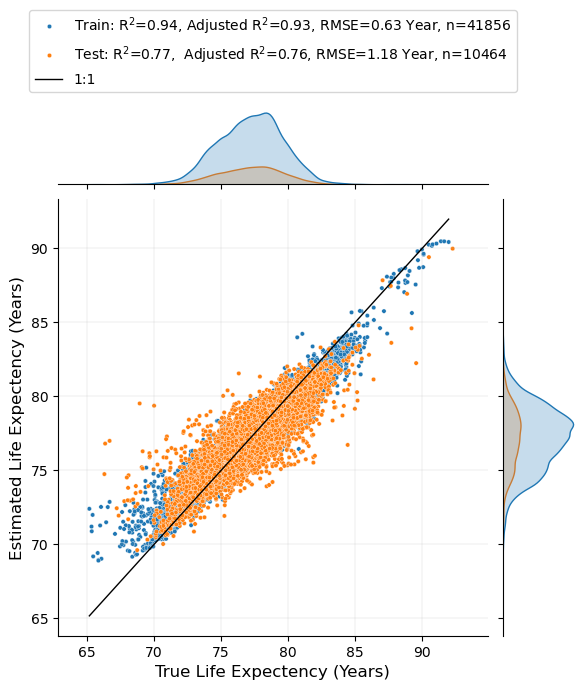

In [36]:
## scatter plot in seaborn

g=sns.jointplot(data=sns_df, x='Actual', y='Estimated', kind="scatter", hue='Label',s=10)
plt.grid(axis='both',linewidth=0.15)

p1 = max(max(train_prediction), max(y_train))
p2 = min(min(train_prediction), min(y_train))

g.ax_joint.plot([p1, p2], [p1, p2], color='k',linewidth=1, label='1:1')

# Customize the legend
handles, labels = g.ax_joint.get_legend_handles_labels()  



g.ax_joint.legend(handles=handles,  
    labels=[ f'Train: R$^2$={corr_train}, Adjusted R$^2$={train_adjusted_r2}, RMSE={rmse_train} Year, n={len(X_train)}', 
        f'Test: R$^2$={corr_test},  Adjusted R$^2$={test_adjusted_r2}, RMSE={rmse_test} Year, n={len(X_test)}','1:1'],
                        title=None)

sns.move_legend(g.ax_joint, "upper center", bbox_to_anchor=(0.5, 1.45))

g.set_axis_labels(r'True Life Expectency (Years)', r'Estimated Life Expectency (Years)',fontsize=12)

plt.show()

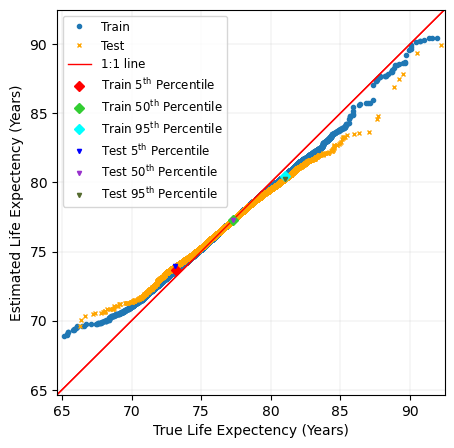

In [37]:
## Lets plot the quantile-quantile plot

fig, ax = plt.subplots(figsize=(5,5))

pp_x = sm.ProbPlot(y_train, fit=False)
pp_y = sm.ProbPlot(train_prediction, fit=False)


qq = pp_y.qqplot(marker='o',markersize=3,other=pp_x,ax=ax, label='Train') ## qq plot for train data
sm.qqline(ax=ax, line='45', fmt='r',linewidth=1)

pp_xx = sm.ProbPlot(y_test, fit=False)
pp_yy = sm.ProbPlot(test_prediction, fit=False)

## overlay qq plot for test data
qqq = pp_yy.qqplot(xlabel='True Life Expectency (Years)',ylabel='Estimated Life Expectency (Years)',
                            marker='x',markersize=3,other=pp_xx,ax=ax,markeredgecolor = 'orange',
                                      markerfacecolor = 'orange', label='Test')

sm.qqline(qq.axes[0], line='45', fmt='r',linewidth=1, label='1:1 line')


## find the percentiles

train_05_actual = df3['Actual'].quantile(0.05)
train_50_actual = df3['Actual'].quantile(0.50)
train_95_actual = df3['Actual'].quantile(0.95)

train_05_estimated = df3['Estimated'].quantile(0.05)
train_50_estimated = df3['Estimated'].quantile(0.50)
train_95_estimated = df3['Estimated'].quantile(0.95)

test_05_actual = df6['Actual'].quantile(0.05)
test_50_actual = df6['Actual'].quantile(0.50)
test_95_actual = df6['Actual'].quantile(0.95)

test_05_estimated = df6['Estimated'].quantile(0.05)
test_50_estimated = df6['Estimated'].quantile(0.50)
test_95_estimated = df6['Estimated'].quantile(0.95)

## plot the percentiles

plt.plot(train_05_actual,train_05_estimated, marker="D",markersize=5,color="red",linestyle ='None',
         label="Train $\\mathrm{5^{th}}$ Percentile")
plt.plot(train_50_actual,train_50_estimated, marker="D",markersize=5,color="limegreen",linestyle ='None',
         label="Train $\\mathrm{50^{th}}$ Percentile")
plt.plot(train_95_actual,train_95_estimated, marker="D",markersize=5,color="Cyan",linestyle ='None',
         label="Train $\\mathrm{95^{th}}$ Percentile")

plt.plot(test_05_actual,test_05_estimated, marker="v",markersize=3,color="blue",linestyle ='None',
         label="Test $\\mathrm{5^{th}}$ Percentile")
plt.plot(test_50_actual,test_50_estimated, marker="v",markersize=3,color="darkorchid",linestyle ='None',
         label="Test $\\mathrm{50^{th}}$ Percentile")
plt.plot(test_95_actual,test_95_estimated, marker="v",markersize=3,color="darkolivegreen",linestyle ='None',
         label="Test $\\mathrm{95^{th}}$ Percentile")


plt.grid(axis='both',linewidth=0.15)
plt.legend(fontsize=8.5)
plt.show()

## Using 5 features

In [38]:
five_features= ['MeanLifeExpectency','Leaf area index, low vegetation','Specific humidity','Leaf area index, high vegetation',
                  'Formaldehyde','Surface pressure']

In [39]:
full_df_five = full_df.loc[:, ten_features]
full_df_five

,MeanLifeExpectency,Specific humidity,"Leaf area index, low vegetation",Surface pressure,"Leaf area index, high vegetation",Sulphate aerosol mixing ratio,Wet bulb temperature,Formaldehyde,Propane,FoT Carbonmonoxide above 90ᵗʰ percentile,Dust aerosol (0.03-0.55 µm) mixing ratio,Isoprene
0,74.628765329999993,0.010010040534155,2.618741604547198,100086.817007783130975,3.904460199286052,0.00000000404404,14.185547266162992,0.000000003513651,0.000000000328437,19.623287671232877,0.000000000654884,0.000000014604292
1,76.661419230000007,0.012053964031284,1.556460793604144,101507.029992429539561,2.493748263318578,0.000000003376943,16.735605496466448,0.000000001813065,0.000000000255961,6.061643835616438,0.000000000693319,0.000000003807398
2,74.047810630000001,0.010116411670589,2.367511530630567,100218.776953070439049,4.174570187840095,0.000000003173645,14.652120108679608,0.000000003130391,0.000000000302966,17.910958904109588,0.000000000696949,0.000000013132761
3,73.057987400000002,0.009712725129444,2.754823872966046,99965.021140069555258,3.638957935933739,0.000000004729935,13.829282111100266,0.000000003373964,0.000000000358899,21.301369863013701,0.0000000006092,0.000000013479486
4,75.053119350000003,0.009374448422807,2.78269651469914,99291.479349611210637,3.286418753252266,0.000000004897891,13.082501247882803,0.000000002956875,0.000000000399657,23.767123287671232,0.000000000565979,0.000000010923979
...,...,...,...,...,...,...,...,...,...,...,...,...
52315,78.018891969999999,0.003747796333939,0.536378170765603,78504.848716287262505,3.538422076256631,0.000000001132903,0.571281695046519,0.000000000717546,0.000000000111938,17.294520547945204,0.000000000301368,0.000000001232036
52316,85.638149490000004,0.003688190466983,1.785488597639217,75982.937825419445289,2.670711888609032,0.000000000875683,-1.859769761436167,0.000000000717248,0.000000000117618,4.178082191780822,0.000000000144742,0.000000001264543
52317,77.521690719999995,0.004073729822701,0.674010337938586,77908.41730284303776,4.031189331292228,0.000000001089012,0.482583691619953,0.000000000815465,0.000000000158386,16.952054794520549,0.000000000192437,0.000000002141827
52318,78.137158389999996,0.004194294518206,0.526594406537813,81987.763448374767904,4.581955061795957,0.000000000867287,0.807879855752541,0.000000000684047,0.000000000108903,17.739726027397261,0.000000000231663,0.00000000077482


In [40]:
## Lets create a Train-Test set

features=full_df_five.drop('MeanLifeExpectency',axis=1)
target=full_df_five['MeanLifeExpectency'].copy()

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.20) 

In [41]:
## initial results

forest_reg=RandomForestRegressor(n_jobs=-1)
forest_reg.fit(X_train, y_train)

train_prediction=forest_reg.predict(X_train)

mse_train=mean_squared_error(y_train, train_prediction)
rmse_train=np.sqrt(mse_train)
rmse_train=int(rmse_train*100)/100 ## display only two digits without rounding

print('The train RMSE :::', '%.2f' % rmse_train)

The train RMSE ::: 0.43


In [42]:
## lets do a cross-validation to identify overfitting and test if there is variation in the output result,
## based on variability of the input data

scores=cross_val_score(forest_reg, X_train, y_train,
                        scoring='neg_mean_squared_error', cv=4, n_jobs=6) ## can select other scoring as well
                                                                          ## n_jobs uses the number of cores
rmse_scores=np.sqrt(-scores)
sd_rmse=rmse_scores.std()
avg_score=rmse_scores.mean()

In [43]:
print(f'RMSE scores for each fold: {rmse_scores}')
print(f'Mean RMSE score: {avg_score}')
print(f'Standard deviation of RMSE scores: {sd_rmse}')

RMSE scores for each fold: [1.25406704 1.21194107 1.22206101 1.2173636 ]
Mean RMSE score: 1.2263581802701553
Standard deviation of RMSE scores: 0.016393610392466947


In [44]:
%%time
## lets optimize the hyperparameters
forest_reg=RandomForestRegressor(n_jobs=-1, oob_score=True) ## also include oob score. this can be removed if not necessary

hyper_parameters=[{'n_estimators':[200, 300],'max_features': [10, 20], 'max_depth':[100, 150],
                                                              'min_samples_split':[ 10, 20]}]
grid_search=GridSearchCV(forest_reg,hyper_parameters,cv=4,scoring="neg_mean_squared_error",return_train_score=True, verbose=1)
grid_search.fit(X_train,y_train)

Fitting 4 folds for each of 16 candidates, totalling 64 fits
CPU times: total: 3h 50min 7s
Wall time: 16min 1s


,estimator,RandomForestR...ob_score=True)
,param_grid,"[{'max_depth': [100, 150], 'max_features': [10, 20], 'min_samples_split': [10, 20], 'n_estimators': [200, 300]}]"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,4
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,300


In [45]:
grid_search.best_estimator_

,n_estimators,300
,criterion,'squared_error'
,max_depth,100
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,20
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [46]:
## lets now select the model. This will be used later
final_model=grid_search.best_estimator_

In [47]:
## fit the model and find the error in the traning set

final_model.fit(X_train,y_train)

train_prediction=final_model.predict(X_train)

mse_train=mean_squared_error(y_train, train_prediction)
rmse_train=np.sqrt(mse_train)
rmse_train=int(rmse_train*100)/100 ## display only two digits without rounding

print('The train RMSE :::', '%.2f' % rmse_train)

The train RMSE ::: 0.62


In [48]:
oob_score=final_model.oob_score_
print(f'OOB score is: {oob_score:.2}') ## oob_score_ is calucalated as R$^2$ between true and estimated 

OOB score is: 0.77


In [49]:
## The test prediction

test_prediction=final_model.predict(X_test)

mse_test=mean_squared_error(y_test,test_prediction)
rmse_test=np.sqrt(mse_test)
rmse_test=int(rmse_test*100)/100 

print('The test RMSE :::', '%.2f' % rmse_test)

The test RMSE ::: 1.18


In [50]:
## the train r square

train_r_sq=(pearsonr(y_train,train_prediction)[0])**2
corr_train=int(train_r_sq*100)/100 ## display only two digits without rounding

print('The train r_sq :::', '%.2f' % corr_train)

The train r_sq ::: 0.94


In [51]:
## The test r square

test_r_sq=(pearsonr(y_test,test_prediction)[0])**2
corr_test=int(test_r_sq*100)/100 ## display only two digits without rounding

print('The test r_sq :::', '%.2f' % corr_test)

The test r_sq ::: 0.77


In [52]:
## calculate the adjusted r square

## in training set

n_train=X_train.shape[0] ## number of samples in training set
n_test=X_test.shape[0]  ## number of samples in test set
p=X_train.shape[1] ## number of features, which is the same in train and test set

train_adjusted_r2=1-(1-corr_train)*((n_train-1)/(n_train-p-1))
train_adjusted_r2=int(train_adjusted_r2*100)/100 ## display only two digits without rounding

test_adjusted_r2=1-(1-corr_test)*((n_test-1)/(n_test-p-1))
test_adjusted_r2=int(test_adjusted_r2*100)/100 ## display only two digits without rounding

print('The adjusted train r_sq :::', '%.2f' % train_adjusted_r2)
print('The adjusted test r_sq :::', '%.2f' % test_adjusted_r2)

The adjusted train r_sq ::: 0.93
The adjusted test r_sq ::: 0.76


In [53]:
## steps to convert train and test to pandas dataframe. This step is necessary to plot in seaborn

y_train_np=y_train.to_numpy() ## convert dtype to numpy to plot from seaborn
y_test_np=y_test.to_numpy() 

df1=pd.DataFrame(y_train_np, columns=['Actual'])
df2=pd.DataFrame(train_prediction, columns=['Estimated'])
df3=pd.concat([df1, df2],axis=1)  ## concatenate the columns
df3['Label']='Train'

df4=pd.DataFrame(y_test_np, columns=['Actual'])
df5=pd.DataFrame(test_prediction, columns=['Estimated'])
df6=pd.concat([df4, df5],axis=1)
df6['Label']='Test'

sns_df=pd.concat([df3,df6])

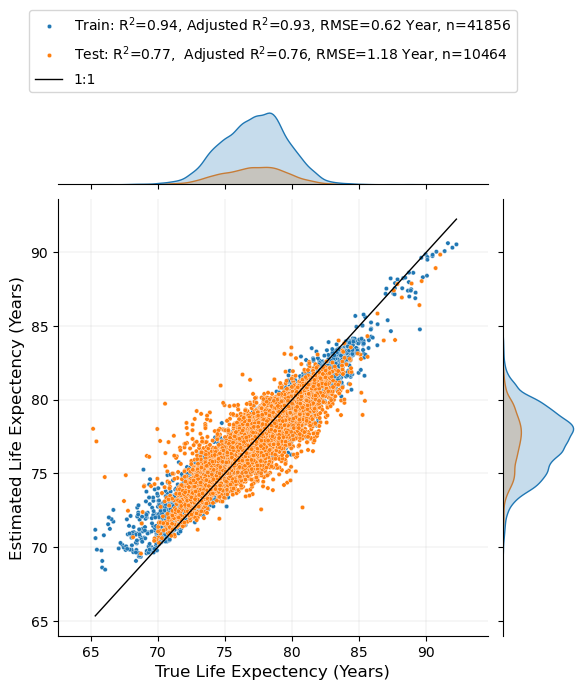

In [54]:
## scatter plot in seaborn

g=sns.jointplot(data=sns_df, x='Actual', y='Estimated', kind="scatter", hue='Label',s=10)
plt.grid(axis='both',linewidth=0.15)

p1 = max(max(train_prediction), max(y_train))
p2 = min(min(train_prediction), min(y_train))

g.ax_joint.plot([p1, p2], [p1, p2], color='k',linewidth=1, label='1:1')

# Customize the legend
handles, labels = g.ax_joint.get_legend_handles_labels()  



g.ax_joint.legend(handles=handles,  
    labels=[ f'Train: R$^2$={corr_train}, Adjusted R$^2$={train_adjusted_r2}, RMSE={rmse_train} Year, n={len(X_train)}', 
        f'Test: R$^2$={corr_test},  Adjusted R$^2$={test_adjusted_r2}, RMSE={rmse_test} Year, n={len(X_test)}','1:1'],
                        title=None)

sns.move_legend(g.ax_joint, "upper center", bbox_to_anchor=(0.5, 1.45))

g.set_axis_labels(r'True Life Expectency (Years)', r'Estimated Life Expectency (Years)',fontsize=12)

plt.show()

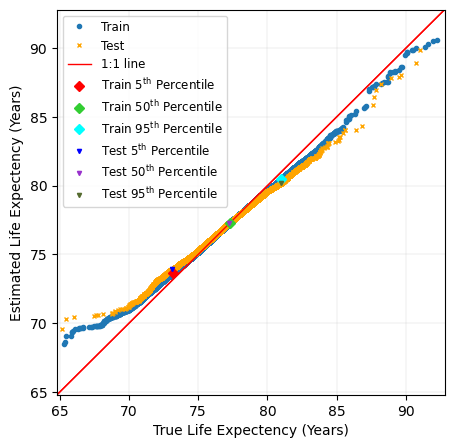

In [55]:
## Lets plot the quantile-quantile plot

fig, ax = plt.subplots(figsize=(5,5))

pp_x = sm.ProbPlot(y_train, fit=False)
pp_y = sm.ProbPlot(train_prediction, fit=False)


qq = pp_y.qqplot(marker='o',markersize=3,other=pp_x,ax=ax, label='Train') ## qq plot for train data
sm.qqline(ax=ax, line='45', fmt='r',linewidth=1)

pp_xx = sm.ProbPlot(y_test, fit=False)
pp_yy = sm.ProbPlot(test_prediction, fit=False)

## overlay qq plot for test data
qqq = pp_yy.qqplot(xlabel='True Life Expectency (Years)',ylabel='Estimated Life Expectency (Years)',
                            marker='x',markersize=3,other=pp_xx,ax=ax,markeredgecolor = 'orange',
                                      markerfacecolor = 'orange', label='Test')

sm.qqline(qq.axes[0], line='45', fmt='r',linewidth=1, label='1:1 line')


## find the percentiles

train_05_actual = df3['Actual'].quantile(0.05)
train_50_actual = df3['Actual'].quantile(0.50)
train_95_actual = df3['Actual'].quantile(0.95)

train_05_estimated = df3['Estimated'].quantile(0.05)
train_50_estimated = df3['Estimated'].quantile(0.50)
train_95_estimated = df3['Estimated'].quantile(0.95)

test_05_actual = df6['Actual'].quantile(0.05)
test_50_actual = df6['Actual'].quantile(0.50)
test_95_actual = df6['Actual'].quantile(0.95)

test_05_estimated = df6['Estimated'].quantile(0.05)
test_50_estimated = df6['Estimated'].quantile(0.50)
test_95_estimated = df6['Estimated'].quantile(0.95)

## plot the percentiles

plt.plot(train_05_actual,train_05_estimated, marker="D",markersize=5,color="red",linestyle ='None',
         label="Train $\\mathrm{5^{th}}$ Percentile")
plt.plot(train_50_actual,train_50_estimated, marker="D",markersize=5,color="limegreen",linestyle ='None',
         label="Train $\\mathrm{50^{th}}$ Percentile")
plt.plot(train_95_actual,train_95_estimated, marker="D",markersize=5,color="Cyan",linestyle ='None',
         label="Train $\\mathrm{95^{th}}$ Percentile")

plt.plot(test_05_actual,test_05_estimated, marker="v",markersize=3,color="blue",linestyle ='None',
         label="Test $\\mathrm{5^{th}}$ Percentile")
plt.plot(test_50_actual,test_50_estimated, marker="v",markersize=3,color="darkorchid",linestyle ='None',
         label="Test $\\mathrm{50^{th}}$ Percentile")
plt.plot(test_95_actual,test_95_estimated, marker="v",markersize=3,color="darkolivegreen",linestyle ='None',
         label="Test $\\mathrm{95^{th}}$ Percentile")


plt.grid(axis='both',linewidth=0.15)
plt.legend(fontsize=8.5)
plt.show()

## Using 3 features

In [74]:
three_features= ['MeanLifeExpectency','Leaf area index, low vegetation','Specific humidity','Leaf area index, high vegetation' ]

In [75]:
full_df_three = full_df.loc[:, three_features]
full_df_three

,MeanLifeExpectency,"Leaf area index, low vegetation",Specific humidity,"Leaf area index, high vegetation"
0,74.628765329999993,2.618741604547198,0.010010040534155,3.904460199286052
1,76.661419230000007,1.556460793604144,0.012053964031284,2.493748263318578
2,74.047810630000001,2.367511530630567,0.010116411670589,4.174570187840095
3,73.057987400000002,2.754823872966046,0.009712725129444,3.638957935933739
4,75.053119350000003,2.78269651469914,0.009374448422807,3.286418753252266
...,...,...,...,...
52315,78.018891969999999,0.536378170765603,0.003747796333939,3.538422076256631
52316,85.638149490000004,1.785488597639217,0.003688190466983,2.670711888609032
52317,77.521690719999995,0.674010337938586,0.004073729822701,4.031189331292228
52318,78.137158389999996,0.526594406537813,0.004194294518206,4.581955061795957


In [76]:
## Lets create a Train-Test set

features=full_df_three.drop('MeanLifeExpectency',axis=1)
target=full_df_three['MeanLifeExpectency'].copy()

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.20) 

In [77]:
## initial results

forest_reg=RandomForestRegressor(n_jobs=-1)
forest_reg.fit(X_train, y_train)

train_prediction=forest_reg.predict(X_train)

mse_train=mean_squared_error(y_train, train_prediction)
rmse_train=np.sqrt(mse_train)
rmse_train=int(rmse_train*100)/100 ## display only two digits without rounding

print('The train RMSE :::', '%.2f' % rmse_train)

The train RMSE ::: 0.42


In [78]:
## lets do a cross-validation to identify overfitting and test if there is variation in the output result,
## based on variability of the input data

scores=cross_val_score(forest_reg, X_train, y_train,
                        scoring='neg_mean_squared_error', cv=4, n_jobs=6) ## can select other scoring as well
                                                                          ## n_jobs uses the number of cores
rmse_scores=np.sqrt(-scores)
sd_rmse=rmse_scores.std()
avg_score=rmse_scores.mean()

In [79]:
print(f'RMSE scores for each fold: {rmse_scores}')
print(f'Mean RMSE score: {avg_score}')
print(f'Standard deviation of RMSE scores: {sd_rmse}')

RMSE scores for each fold: [1.22665348 1.20194374 1.22277795 1.20464108]
Mean RMSE score: 1.2140040621488704
Standard deviation of RMSE scores: 0.010840959942046435


In [80]:
%%time
## lets optimize the hyperparameters
forest_reg=RandomForestRegressor(n_jobs=-1, oob_score=True) ## also include oob score. this can be removed if not necessary

hyper_parameters=[{'n_estimators':[200, 300],'max_features': [10, 20], 'max_depth':[100, 150],
                                                              'min_samples_split':[ 10, 20]}]
grid_search=GridSearchCV(forest_reg,hyper_parameters,cv=4,scoring="neg_mean_squared_error",return_train_score=True, verbose=1)
grid_search.fit(X_train,y_train)

Fitting 4 folds for each of 16 candidates, totalling 64 fits
CPU times: total: 40min 19s
Wall time: 3min 36s


,estimator,RandomForestR...ob_score=True)
,param_grid,"[{'max_depth': [100, 150], 'max_features': [10, 20], 'min_samples_split': [10, 20], 'n_estimators': [200, 300]}]"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,4
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,300


In [81]:
grid_search.best_estimator_

,n_estimators,300
,criterion,'squared_error'
,max_depth,150
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,10
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [82]:
## lets now select the model. This will be used later
final_model=grid_search.best_estimator_

In [83]:
## fit the model and find the error in the traning set

final_model.fit(X_train,y_train)

train_prediction=final_model.predict(X_train)

mse_train=mean_squared_error(y_train, train_prediction)
rmse_train=np.sqrt(mse_train)
rmse_train=int(rmse_train*100)/100 ## display only two digits without rounding

print('The train RMSE :::', '%.2f' % rmse_train)

The train RMSE ::: 0.71


In [84]:
oob_score=final_model.oob_score_
print(f'OOB score is: {oob_score:.2}') ## oob_score_ is calucalated as R$^2$ between true and estimated 

OOB score is: 0.76


In [85]:
## The test prediction

test_prediction=final_model.predict(X_test)

mse_test=mean_squared_error(y_test,test_prediction)
rmse_test=np.sqrt(mse_test)
rmse_test=int(rmse_test*100)/100 

print('The test RMSE :::', '%.2f' % rmse_test)

The test RMSE ::: 1.16


In [86]:
## the train r square

train_r_sq=(pearsonr(y_train,train_prediction)[0])**2
corr_train=int(train_r_sq*100)/100 ## display only two digits without rounding

print('The train r_sq :::', '%.2f' % corr_train)

The train r_sq ::: 0.92


In [87]:
## The test r square

test_r_sq=(pearsonr(y_test,test_prediction)[0])**2
corr_test=int(test_r_sq*100)/100 ## display only two digits without rounding

print('The test r_sq :::', '%.2f' % corr_test)

The test r_sq ::: 0.77


In [88]:
## calculate the adjusted r square

## in training set

n_train=X_train.shape[0] ## number of samples in training set
n_test=X_test.shape[0]  ## number of samples in test set
p=X_train.shape[1] ## number of features, which is the same in train and test set

train_adjusted_r2=1-(1-corr_train)*((n_train-1)/(n_train-p-1))
train_adjusted_r2=int(train_adjusted_r2*100)/100 ## display only two digits without rounding

test_adjusted_r2=1-(1-corr_test)*((n_test-1)/(n_test-p-1))
test_adjusted_r2=int(test_adjusted_r2*100)/100 ## display only two digits without rounding

print('The adjusted train r_sq :::', '%.2f' % train_adjusted_r2)
print('The adjusted test r_sq :::', '%.2f' % test_adjusted_r2)

The adjusted train r_sq ::: 0.91
The adjusted test r_sq ::: 0.76


In [89]:
## steps to convert train and test to pandas dataframe. This step is necessary to plot in seaborn

y_train_np=y_train.to_numpy() ## convert dtype to numpy to plot from seaborn
y_test_np=y_test.to_numpy() 

df1=pd.DataFrame(y_train_np, columns=['Actual'])
df2=pd.DataFrame(train_prediction, columns=['Estimated'])
df3=pd.concat([df1, df2],axis=1)  ## concatenate the columns
df3['Label']='Train'

df4=pd.DataFrame(y_test_np, columns=['Actual'])
df5=pd.DataFrame(test_prediction, columns=['Estimated'])
df6=pd.concat([df4, df5],axis=1)
df6['Label']='Test'

sns_df=pd.concat([df3,df6])

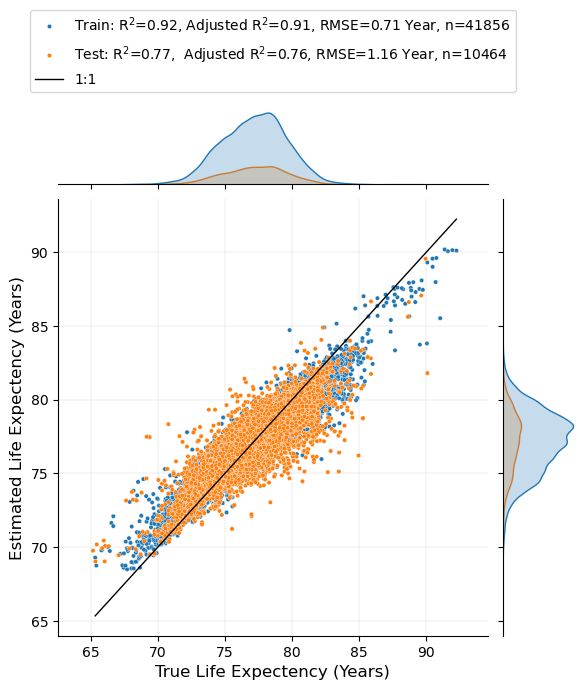

In [90]:
## scatter plot in seaborn

g=sns.jointplot(data=sns_df, x='Actual', y='Estimated', kind="scatter", hue='Label',s=10)
plt.grid(axis='both',linewidth=0.15)

p1 = max(max(train_prediction), max(y_train))
p2 = min(min(train_prediction), min(y_train))

g.ax_joint.plot([p1, p2], [p1, p2], color='k',linewidth=1, label='1:1')

# Customize the legend
handles, labels = g.ax_joint.get_legend_handles_labels()  



g.ax_joint.legend(handles=handles,  
    labels=[ f'Train: R$^2$={corr_train}, Adjusted R$^2$={train_adjusted_r2}, RMSE={rmse_train} Year, n={len(X_train)}', 
        f'Test: R$^2$={corr_test},  Adjusted R$^2$={test_adjusted_r2}, RMSE={rmse_test} Year, n={len(X_test)}','1:1'],
                        title=None)

sns.move_legend(g.ax_joint, "upper center", bbox_to_anchor=(0.5, 1.45))

g.set_axis_labels(r'True Life Expectency (Years)', r'Estimated Life Expectency (Years)',fontsize=12)

plt.show()

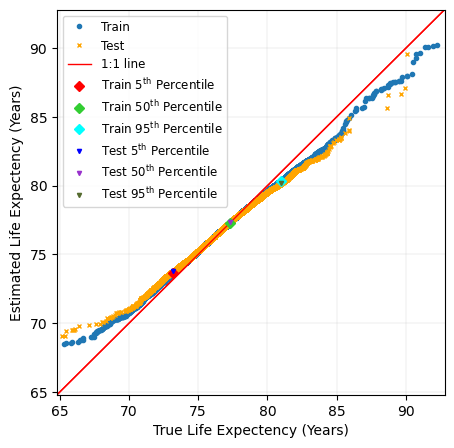

In [91]:
## Lets plot the quantile-quantile plot

fig, ax = plt.subplots(figsize=(5,5))

pp_x = sm.ProbPlot(y_train, fit=False)
pp_y = sm.ProbPlot(train_prediction, fit=False)


qq = pp_y.qqplot(marker='o',markersize=3,other=pp_x,ax=ax, label='Train') ## qq plot for train data
sm.qqline(ax=ax, line='45', fmt='r',linewidth=1)

pp_xx = sm.ProbPlot(y_test, fit=False)
pp_yy = sm.ProbPlot(test_prediction, fit=False)

## overlay qq plot for test data
qqq = pp_yy.qqplot(xlabel='True Life Expectency (Years)',ylabel='Estimated Life Expectency (Years)',
                            marker='x',markersize=3,other=pp_xx,ax=ax,markeredgecolor = 'orange',
                                      markerfacecolor = 'orange', label='Test')

sm.qqline(qq.axes[0], line='45', fmt='r',linewidth=1, label='1:1 line')


## find the percentiles

train_05_actual = df3['Actual'].quantile(0.05)
train_50_actual = df3['Actual'].quantile(0.50)
train_95_actual = df3['Actual'].quantile(0.95)

train_05_estimated = df3['Estimated'].quantile(0.05)
train_50_estimated = df3['Estimated'].quantile(0.50)
train_95_estimated = df3['Estimated'].quantile(0.95)

test_05_actual = df6['Actual'].quantile(0.05)
test_50_actual = df6['Actual'].quantile(0.50)
test_95_actual = df6['Actual'].quantile(0.95)

test_05_estimated = df6['Estimated'].quantile(0.05)
test_50_estimated = df6['Estimated'].quantile(0.50)
test_95_estimated = df6['Estimated'].quantile(0.95)

## plot the percentiles

plt.plot(train_05_actual,train_05_estimated, marker="D",markersize=5,color="red",linestyle ='None',
         label="Train $\\mathrm{5^{th}}$ Percentile")
plt.plot(train_50_actual,train_50_estimated, marker="D",markersize=5,color="limegreen",linestyle ='None',
         label="Train $\\mathrm{50^{th}}$ Percentile")
plt.plot(train_95_actual,train_95_estimated, marker="D",markersize=5,color="Cyan",linestyle ='None',
         label="Train $\\mathrm{95^{th}}$ Percentile")

plt.plot(test_05_actual,test_05_estimated, marker="v",markersize=3,color="blue",linestyle ='None',
         label="Test $\\mathrm{5^{th}}$ Percentile")
plt.plot(test_50_actual,test_50_estimated, marker="v",markersize=3,color="darkorchid",linestyle ='None',
         label="Test $\\mathrm{50^{th}}$ Percentile")
plt.plot(test_95_actual,test_95_estimated, marker="v",markersize=3,color="darkolivegreen",linestyle ='None',
         label="Test $\\mathrm{95^{th}}$ Percentile")


plt.grid(axis='both',linewidth=0.15)
plt.legend(fontsize=8.5)
plt.show()